# Week 4: Data Visualization

# Applied Statistics with Python (2026)

---

> "A picture is worth a thousand numbers."  

Visualization is how we **see** patterns, outliers, and relationships in data.  
This week we learn two libraries:

- **Matplotlib** — the foundational plotting library (low-level, full control)
- **Seaborn** — built on Matplotlib, designed for **statistical** graphics (high-level, beautiful defaults)

### What We'll Cover

| # | Topic |
|---|-------|
| 1 | Matplotlib Basics: Figure, Axes, `plt.plot()` |
| 2 | Line Plot |
| 3 | Bar Chart |
| 4 | Histogram |
| 5 | Scatter Plot |
| 6 | Pie Chart |
| 7 | Subplots — Multiple Plots in One Figure |
| 8 | Customization: Colors, Styles, Annotations |
| 9 | Seaborn Introduction |
| 10 | Seaborn: Distribution Plots |
| 11 | Seaborn: Categorical Plots |
| 12 | Seaborn: Relational & Regression Plots |
| 13 | Seaborn: Heatmap |
| 14 | Choosing the Right Chart |
| 15 | Summary & Homework |

Import the libraries and configure Jupyter to display plots inline.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Optional: higher-resolution plots for Retina displays
%config InlineBackend.figure_format = 'retina'

print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn:    {sns.__version__}")

Matplotlib: 3.10.0
Seaborn:    0.13.2


---
## 1. Matplotlib Basics: Figure and Axes

### The Architecture

Every Matplotlib plot has two layers:

- **Figure** — the overall window/canvas (like a blank sheet of paper)
- **Axes** — the actual plot area where data is drawn (you can have multiple Axes in one Figure)

```
┌─────────────────── Figure ──────────────────┐
│                                              │
│   ┌──────── Axes ────────┐                   │
│   │  Title               │                   │
│   │  ┌──────────────┐    │                   │
│   │  │              │    │                   │
│   │  │   Plot Area  │    │                   │
│   │  │              │    │                   │
│   │  └──────────────┘    │                   │
│   │  X-axis label        │                   │
│   └──────────────────────┘                   │
│                                              │
└──────────────────────────────────────────────┘
```

There are **two coding styles** in Matplotlib:

| Style | Code | Best For |
|-------|------|----------|
| **pyplot** (state-based) | `plt.plot()`, `plt.xlabel()` | Quick, single plots |
| **Object-oriented** | `fig, ax = plt.subplots()` | Multi-plot figures, full control |

We'll use both, but **prefer the OO style** for anything beyond a quick sketch.

### 1.1 The Simplest Plot

Let's start with the `plt.plot()` shorthand — just pass x and y data.

In [ ]:
# Simple line plot using pyplot style
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

plt.plot(x, y)           # Draw the line
plt.title("My First Plot")  # Add title
plt.xlabel("X")          # Label x-axis
plt.ylabel("Y")          # Label y-axis
plt.show()               # Display the plot

### 1.2 Object-Oriented Style

The recommended approach — `fig, ax = plt.subplots()` gives you explicit control over Figure and Axes.

In [ ]:
# Same plot, object-oriented style
fig, ax = plt.subplots(figsize=(6, 4))  # Create figure + axes

ax.plot(x, y)             # Plot on the axes
ax.set_title("OO Style Plot")  # Note: set_title, not title
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.tight_layout()        # Auto-adjust spacing
plt.show()

---
## 2. Line Plot

Line plots show **trends over a continuous variable** (usually time or sequence).  
Best for: time series, growth curves, comparing trends.

### 2.1 Single Line

Plot weekly quiz scores for one student across a semester.

In [ ]:
# Weekly quiz scores
weeks = np.arange(1, 13)  # Week 1-12
scores = [72, 75, 68, 78, 82, 79, 85, 88, 84, 90, 92, 95]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(weeks, scores,
        marker='o',          # Circle markers at each point
        linewidth=2,         # Line thickness
        color='steelblue',   # Line color
        markersize=6)        # Marker size

ax.set_title("Alice's Quiz Scores Over the Semester", fontsize=14)
ax.set_xlabel("Week", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_xticks(weeks)         # Show every week on x-axis
ax.set_ylim(60, 100)         # y-axis range
ax.grid(True, alpha=0.3)     # Light grid lines

plt.tight_layout()
plt.show()

### 2.2 Multiple Lines

Compare trends by plotting multiple lines on the same axes.

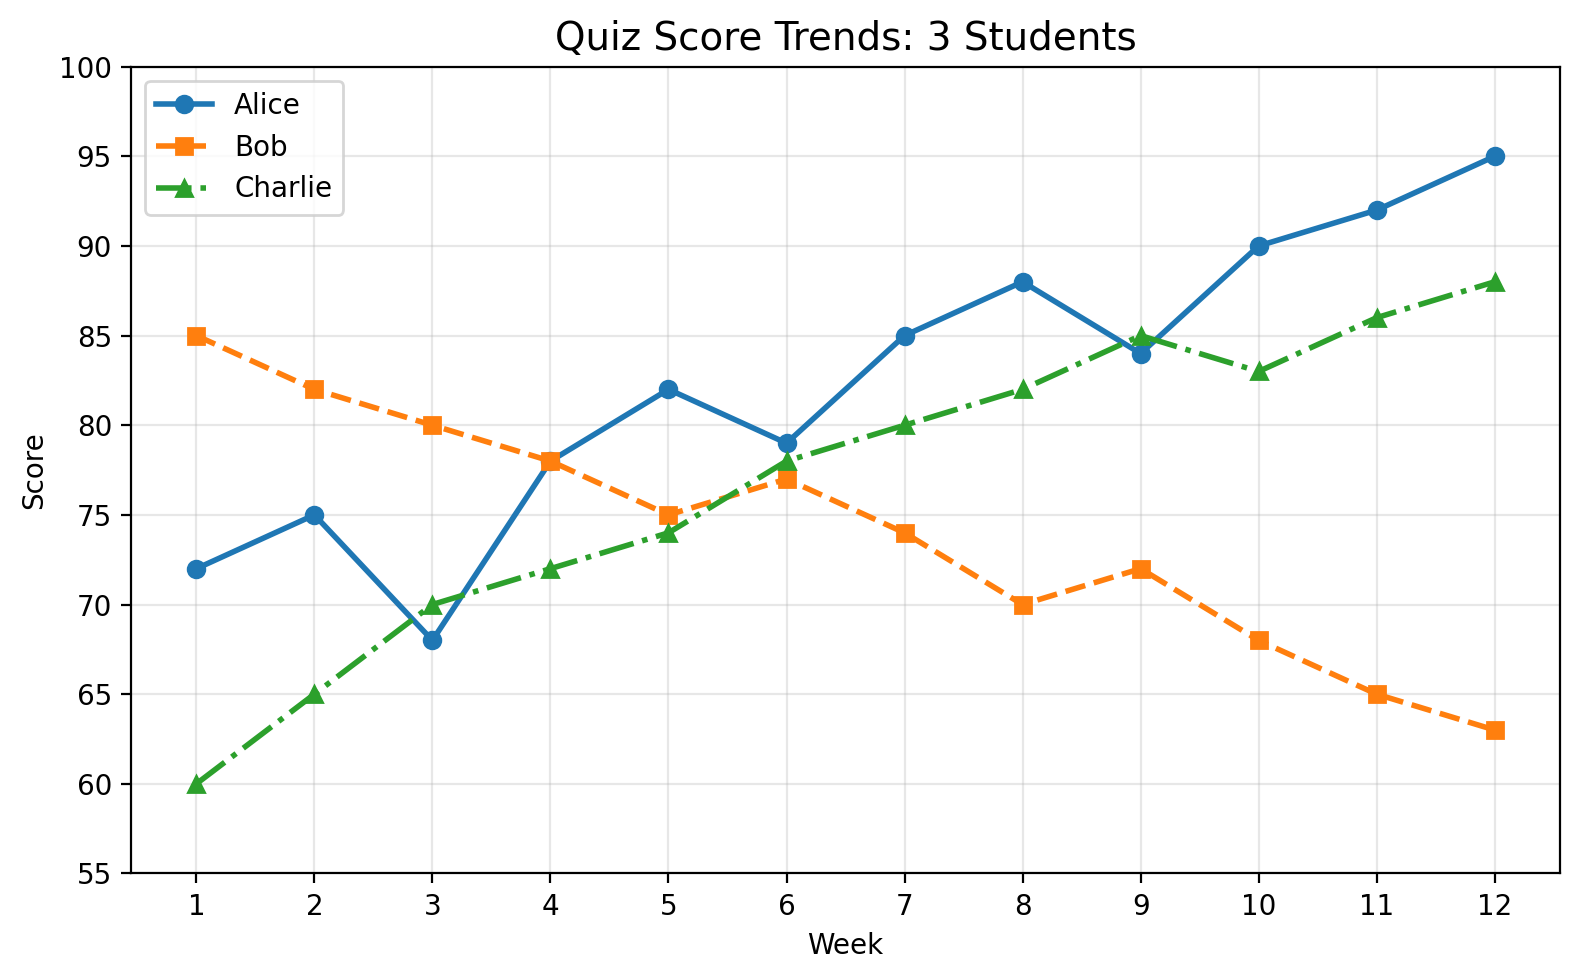

In [3]:
# Compare 3 students
weeks = np.arange(1, 13)
alice  = [72, 75, 68, 78, 82, 79, 85, 88, 84, 90, 92, 95]
bob    = [85, 82, 80, 78, 75, 77, 74, 70, 72, 68, 65, 63]
charlie = [60, 65, 70, 72, 74, 78, 80, 82, 85, 83, 86, 88]

fig, ax = plt.subplots(figsize=(8, 5))

# Plot each student with different styles
ax.plot(weeks, alice,   marker='o', label='Alice',   linewidth=2)
ax.plot(weeks, bob,     marker='s', label='Bob',     linewidth=2, linestyle='--')
ax.plot(weeks, charlie, marker='^', label='Charlie', linewidth=2, linestyle='-.')

ax.set_title("Quiz Score Trends: 3 Students", fontsize=14)
ax.set_xlabel("Week")
ax.set_ylabel("Score")
ax.set_xticks(weeks)
ax.set_ylim(55, 100)
ax.legend()                  # Show the legend
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Mathematical Functions

Line plots are perfect for visualizing mathematical functions — use `np.linspace()` for smooth curves.

In [ ]:
# Plot sin and cos curves
x = np.linspace(0, 2 * np.pi, 200)  # 200 points for smooth curve

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, np.sin(x), label='sin(x)', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', linewidth=2, linestyle='--')

ax.axhline(y=0, color='black', linewidth=0.5)  # Horizontal line at y=0
ax.set_title("Trigonometric Functions", fontsize=14)
ax.set_xlabel("x (radians)")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Bar Chart

Bar charts compare **quantities across categories**.  
Best for: comparing groups, showing distributions of categorical data.

### 3.1 Vertical Bar Chart

Compare the average scores of different majors.

In [ ]:
# Average scores by major
majors = ['Data Science', 'Statistics', 'Math', 'CS']
averages = [83.5, 79.2, 81.8, 76.4]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(majors, averages,
              color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],  # Custom colors
              edgecolor='white',   # White border
              width=0.6)           # Bar width

# Add value labels on top of each bar
for bar, val in zip(bars, averages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11)

ax.set_title("Average Score by Major", fontsize=14)
ax.set_ylabel("Average Score")
ax.set_ylim(0, 95)  # Leave space for labels

plt.tight_layout()
plt.show()

### 3.2 Horizontal Bar Chart

Use `barh()` when category names are long — easier to read.

In [ ]:
# Horizontal bar chart — sorted for easy comparison
students = ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry']
scores = [92, 78, 85, 95, 67, 88, 72, 90]

# Sort by score
sorted_pairs = sorted(zip(scores, students))  # Sort by score
sorted_scores, sorted_names = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(7, 5))

# Color bars by score range
colors = ['#C44E52' if s < 70 else '#CCB974' if s < 80 else '#55A868'
          for s in sorted_scores]

ax.barh(sorted_names, sorted_scores, color=colors, edgecolor='white')
ax.set_title("Student Scores (Sorted)", fontsize=14)
ax.set_xlabel("Score")
ax.set_xlim(0, 105)

# Add value labels
for i, (score, name) in enumerate(zip(sorted_scores, sorted_names)):
    ax.text(score + 1, i, str(score), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 3.3 Grouped Bar Chart

Compare multiple metrics side by side for each category.

In [ ]:
# Midterm vs Final by major
majors = ['DS', 'Stats', 'Math', 'CS']
midterm = [82, 78, 85, 75]
final   = [88, 80, 83, 79]

x = np.arange(len(majors))  # Category positions: [0, 1, 2, 3]
width = 0.35                # Width of each bar

fig, ax = plt.subplots(figsize=(7, 5))

# Place bars side by side using offset
bars1 = ax.bar(x - width/2, midterm, width, label='Midterm', color='#4C72B0')
bars2 = ax.bar(x + width/2, final,   width, label='Final',   color='#55A868')

ax.set_title("Midterm vs Final by Major", fontsize=14)
ax.set_ylabel("Average Score")
ax.set_xticks(x)
ax.set_xticklabels(majors)
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

---
## 4. Histogram

A histogram shows the **distribution** of a continuous variable — how often values fall into each range (bin).  
Best for: understanding the shape of your data (normal? skewed? bimodal?).

### 4.1 Basic Histogram

Generate 500 exam scores from a normal distribution and visualize their distribution.

In [ ]:
# Simulate exam scores
rng = np.random.default_rng(42)
scores = rng.normal(loc=72, scale=12, size=500).clip(0, 100)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(scores,
        bins=20,             # Number of bins
        color='steelblue',   # Fill color
        edgecolor='white',   # Bin border color
        alpha=0.8)           # Transparency

# Add a vertical line at the mean
ax.axvline(scores.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {scores.mean():.1f}')

ax.set_title("Distribution of Exam Scores (n=500)", fontsize=14)
ax.set_xlabel("Score")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.show()

### 4.2 Effect of Bin Size

The number of bins dramatically affects how the distribution looks. Too few bins lose detail; too many bins create noise.

In [1]:
# Compare different bin sizes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, n_bins in zip(axes, [5, 20, 50]):
    ax.hist(scores, bins=n_bins, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'bins = {n_bins}', fontsize=13)
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')

plt.suptitle("Effect of Bin Size on Histogram Shape", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### 4.3 Overlapping Histograms

Compare the distributions of two groups on the same plot.

In [ ]:
# Two groups of students
rng = np.random.default_rng(42)
group_a = rng.normal(75, 10, 300).clip(0, 100)  # Regular class
group_b = rng.normal(82, 8, 300).clip(0, 100)   # Honors class

fig, ax = plt.subplots(figsize=(8, 5))

# Use alpha for transparency so overlaps are visible
ax.hist(group_a, bins=20, alpha=0.6, color='#4C72B0',
        label=f'Regular (mean={group_a.mean():.1f})', edgecolor='white')
ax.hist(group_b, bins=20, alpha=0.6, color='#C44E52',
        label=f'Honors (mean={group_b.mean():.1f})', edgecolor='white')

ax.set_title("Score Distribution: Regular vs Honors", fontsize=14)
ax.set_xlabel("Score")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.show()

---
## 5. Scatter Plot

Scatter plots reveal **relationships between two continuous variables**.  
Best for: correlation, clusters, outliers.

### 5.1 Basic Scatter Plot

Do students who study more score higher? Let's visualize study hours vs exam scores.

In [ ]:
# Simulate: study hours vs score
rng = np.random.default_rng(42)
n = 80
study_hours = rng.uniform(1, 12, n)
scores = 50 + 3.5 * study_hours + rng.normal(0, 6, n)  # Linear + noise
scores = np.clip(scores, 0, 100)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(study_hours, scores,
           alpha=0.6,           # Transparency for overlapping points
           color='steelblue',
           edgecolor='white',
           s=50)                # Marker size

ax.set_title("Study Hours vs Exam Score", fontsize=14)
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Scatter with Trend Line

Add a linear regression line to see the overall trend more clearly.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# Scatter points
ax.scatter(study_hours, scores, alpha=0.6, color='steelblue',
           edgecolor='white', s=50)

# Trend line using np.polyfit (linear regression)
coeffs = np.polyfit(study_hours, scores, 1)  # Degree 1 = linear
trend_x = np.linspace(study_hours.min(), study_hours.max(), 100)
trend_y = np.polyval(coeffs, trend_x)
ax.plot(trend_x, trend_y, color='red', linewidth=2,
        label=f'Trend: y = {coeffs[0]:.1f}x + {coeffs[1]:.1f}')

# Correlation coefficient
r = np.corrcoef(study_hours, scores)[0, 1]
ax.set_title(f"Study Hours vs Score (r = {r:.3f})", fontsize=14)
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Scatter with Color and Size Encoding

Use color and size to encode extra dimensions — visualize 4 variables in one 2D plot.

In [ ]:
# 4 dimensions: x=study hours, y=score, color=GPA, size=age
rng = np.random.default_rng(42)
n = 60
hours = rng.uniform(2, 12, n)
exam = 45 + 3.5 * hours + rng.normal(0, 7, n)
gpa = 2.0 + 0.15 * hours + rng.normal(0, 0.3, n)
gpa = np.clip(gpa, 2.0, 4.0)
ages = rng.integers(19, 25, n)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(hours, exam,
                     c=gpa,             # Color by GPA
                     s=ages * 8,        # Size by age
                     cmap='RdYlGn',     # Red-Yellow-Green colormap
                     alpha=0.7,
                     edgecolor='gray')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('GPA')

ax.set_title("Multi-dimensional Student Data", fontsize=14)
ax.set_xlabel("Study Hours")
ax.set_ylabel("Exam Score")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Pie Chart

Pie charts show **proportions of a whole**. Use sparingly — bar charts are often more readable.  
Best for: showing composition when there are **few categories** (3–6).

Visualize the grade distribution of a class.

In [ ]:
# Grade distribution
grades = ['A', 'B', 'C', 'D', 'F']
counts = [8, 15, 12, 4, 1]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
explode = [0.05, 0, 0, 0, 0.1]  # Slightly separate A and F slices

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=grades,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',      # Show percentage inside each slice
    startangle=90,           # Start from top
    textprops={'fontsize': 12}
)

# Make percentage text bold and white
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title("Grade Distribution (n=40)", fontsize=14)

plt.tight_layout()
plt.show()

---
## 7. Subplots — Multiple Plots in One Figure

Use `plt.subplots(nrows, ncols)` to create a grid of plots.  
This is essential for comparing different views of the same data side by side.

### 7.1 Basic Grid Layout

Create a 2×2 grid showing four different chart types for the same dataset.

In [ ]:
rng = np.random.default_rng(42)
scores = rng.normal(75, 12, 200).clip(0, 100)

# 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Top-left: Histogram
axes[0, 0].hist(scores, bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Histogram')
axes[0, 0].set_xlabel('Score')

# Top-right: Box plot
axes[0, 1].boxplot(scores, vert=True)
axes[0, 1].set_title('Box Plot')
axes[0, 1].set_ylabel('Score')

# Bottom-left: Line plot (sorted scores = cumulative view)
axes[1, 0].plot(np.sort(scores), marker='.', markersize=2, linewidth=0)
axes[1, 0].set_title('Sorted Scores')
axes[1, 0].set_xlabel('Rank')
axes[1, 0].set_ylabel('Score')

# Bottom-right: Grade bar chart
grade_labels = ['A (≥90)', 'B (80-89)', 'C (70-79)', 'D (60-69)', 'F (<60)']
grade_counts = [
    np.sum(scores >= 90), np.sum((scores >= 80) & (scores < 90)),
    np.sum((scores >= 70) & (scores < 80)), np.sum((scores >= 60) & (scores < 70)),
    np.sum(scores < 60)
]
axes[1, 1].bar(grade_labels, grade_counts,
               color=['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c'])
axes[1, 1].set_title('Grade Distribution')
axes[1, 1].tick_params(axis='x', rotation=30)  # Rotate labels

plt.suptitle('Exam Scores: Four Views (n=200)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Customization: Colors, Styles, Annotations

Good visualizations are not just correct — they are **readable, clean, and informative**.

### 8.1 Built-in Styles

Matplotlib has many built-in styles that change the entire look of your plots.

In [ ]:
# Available styles
print("Available styles:")
print(plt.style.available)

Let's compare how the same plot looks with different styles.

In [ ]:
# Compare 4 popular styles
x = np.linspace(0, 10, 100)
style_list = ['default', 'seaborn-v0_8', 'ggplot', 'fivethirtyeight']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, style_name in zip(axes.flat, style_list):
    with plt.style.context(style_name):  # Temporary style
        ax.plot(x, np.sin(x), label='sin(x)')
        ax.plot(x, np.cos(x), label='cos(x)')
        ax.set_title(f'Style: {style_name}', fontsize=12)
        ax.legend(fontsize=9)

plt.suptitle('Matplotlib Style Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8.2 Color Palettes

Color is a powerful channel for encoding information. Here are some common colormaps.

In [ ]:
# Demonstrate colormaps
rng = np.random.default_rng(42)
data = rng.random((10, 10))  # 10x10 random matrix

cmaps = ['viridis', 'plasma', 'coolwarm', 'RdYlGn']

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, cmap in zip(axes, cmaps):
    im = ax.imshow(data, cmap=cmap)    # Show matrix as colored image
    ax.set_title(cmap, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)  # Add colorbar
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Popular Colormaps', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 8.3 Annotations and Text

Annotations highlight specific data points — use arrows and text to tell a story.

In [ ]:
# Annotated line chart
months = np.arange(1, 13)
revenue = [120, 135, 148, 162, 155, 170, 188, 195, 210, 225, 240, 260]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(months, revenue, marker='o', linewidth=2, color='steelblue')

# Annotate the peak
max_idx = np.argmax(revenue)
ax.annotate(f'Peak: ${revenue[max_idx]}K',
            xy=(months[max_idx], revenue[max_idx]),       # Point to annotate
            xytext=(months[max_idx]-2, revenue[max_idx]+15),  # Text position
            fontsize=12,
            arrowprops=dict(arrowstyle='->', color='red'),  # Arrow style
            color='red', fontweight='bold')

# Annotate the dip
ax.annotate('Summer dip',
            xy=(5, revenue[4]),
            xytext=(3, revenue[4]-20),
            fontsize=11,
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_title('Monthly Revenue (2025)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')
ax.set_xticks(months)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.4 Saving Figures

Save plots to files for presentations or reports.

In [ ]:
# Save to file
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3, 4], [10, 20, 25, 30], marker='o')
ax.set_title('Sample Plot')

# Common formats: png, pdf, svg
fig.savefig('sample_plot.png', dpi=150, bbox_inches='tight')  # PNG for web
# fig.savefig('sample_plot.pdf', bbox_inches='tight')  # PDF for papers
# fig.savefig('sample_plot.svg', bbox_inches='tight')  # SVG for scalable

print("Plot saved as 'sample_plot.png'")
plt.show()

---
## 9. Seaborn Introduction

### Why Seaborn?

Seaborn is a **statistical visualization library** built on top of Matplotlib.  
It provides:

| Feature | Matplotlib | Seaborn |
|---------|-----------|--------|
| Default style | Basic | Beautiful |
| Statistical plots | Manual | Built-in |
| Pandas integration | Partial | Native |
| Color palettes | Limited | Rich |
| Complexity | Low-level | High-level |

**Rule of thumb:**
- Use **Seaborn** when working with DataFrames and statistical plots
- Use **Matplotlib** when you need fine-grained control or custom layouts
- They work **together** — Seaborn creates plots; Matplotlib customizes them

Let's create a sample DataFrame to use throughout the Seaborn sections.

In [ ]:
# Create sample student dataset
rng = np.random.default_rng(2026)
n = 120

df = pd.DataFrame({
    'Major':    rng.choice(['Data Science', 'Statistics', 'Math', 'CS'], n),
    'Gender':   rng.choice(['M', 'F'], n),
    'Age':      rng.integers(19, 25, n),
    'Midterm':  rng.normal(75, 12, n).clip(30, 100).round(1),
    'Final':    rng.normal(72, 14, n).clip(30, 100).round(1),
    'Homework': rng.normal(80, 8, n).clip(40, 100).round(1),
    'StudyHrs': rng.uniform(2, 14, n).round(1),
})
df['Average'] = (df['Midterm']*0.3 + df['Final']*0.5 + df['Homework']*0.2).round(1)

print(f"Shape: {df.shape}")
df.head()

### 9.1 Seaborn Global Settings

`sns.set_theme()` sets the default style and context for all subsequent plots.

In [ ]:
# Set Seaborn style globally
sns.set_theme(
    style='whitegrid',    # Options: darkgrid, whitegrid, dark, white, ticks
    context='notebook',   # Options: paper, notebook, talk, poster
    palette='muted',      # Default color palette
    font_scale=1.1        # Scale all text
)

print("Seaborn theme set: whitegrid, notebook context")

---
## 10. Seaborn: Distribution Plots

Distribution plots answer the question: **"What does my data look like?"**

### 10.1 `histplot()` — Histogram

Seaborn's `histplot()` integrates with Pandas — just pass column names and a DataFrame.

In [ ]:
# Histogram with optional KDE (Kernel Density Estimate) overlay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: basic histogram
sns.histplot(data=df, x='Average', bins=20, ax=axes[0])
axes[0].set_title('Histogram of Average Scores')

# Right: histogram + KDE + hue by gender
sns.histplot(data=df, x='Average', hue='Gender', kde=True,
             bins=15, alpha=0.5, ax=axes[1])
axes[1].set_title('Average Scores by Gender')

plt.tight_layout()
plt.show()

### 10.2 `kdeplot()` — Kernel Density Estimation

KDE creates a **smooth, continuous estimate** of the distribution — like a smoothed histogram.

In [ ]:
# KDE by Major
fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(data=df, x='Average', hue='Major',
            fill=True,       # Fill under curve
            alpha=0.3,       # Transparency
            linewidth=2,
            ax=ax)

ax.set_title('Score Distribution by Major (KDE)', fontsize=14)
ax.set_xlabel('Average Score')

plt.tight_layout()
plt.show()

### 10.3 `boxplot()` — Box and Whisker Plot

Box plots show the **five-number summary** (min, Q1, median, Q3, max) plus outliers.  
Essential for comparing distributions across groups.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: box plot by Major
sns.boxplot(data=df, x='Major', y='Average', ax=axes[0])
axes[0].set_title('Score Distribution by Major')
axes[0].tick_params(axis='x', rotation=15)

# Right: box plot by Major, split by Gender
sns.boxplot(data=df, x='Major', y='Average', hue='Gender', ax=axes[1])
axes[1].set_title('Score by Major and Gender')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 10.4 `violinplot()` — Distribution Shape + Box Plot

A violin plot combines a box plot with a KDE on each side — shows the full distribution shape.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(data=df, x='Major', y='Average',
               inner='box',    # Show box plot inside
               palette='Set2',
               ax=ax)

ax.set_title('Score Distribution by Major (Violin Plot)', fontsize=14)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---
## 11. Seaborn: Categorical Plots

These plots show relationships between **categorical** and **numeric** variables.

### 11.1 `countplot()` — Count of Each Category

How many students are in each major? Split by gender?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: simple count
sns.countplot(data=df, x='Major', order=df['Major'].value_counts().index,
              ax=axes[0])
axes[0].set_title('Student Count by Major')
axes[0].tick_params(axis='x', rotation=15)

# Right: count split by gender
sns.countplot(data=df, x='Major', hue='Gender',
              order=df['Major'].value_counts().index, ax=axes[1])
axes[1].set_title('Student Count by Major & Gender')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 11.2 `barplot()` — Mean with Confidence Interval

Seaborn's `barplot()` automatically calculates the **mean** and shows a **95% confidence interval** error bar.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Bar shows mean; error bar shows 95% CI
sns.barplot(data=df, x='Major', y='Average', hue='Gender',
            palette='Set2', ax=ax)

ax.set_title('Mean Average Score by Major & Gender (with 95% CI)', fontsize=13)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 11.3 `stripplot()` and `swarmplot()` — Show Individual Points

Strip and swarm plots show **every data point**, not just summaries. Useful for small to medium datasets.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: strip plot (random jitter)
sns.stripplot(data=df, x='Major', y='Average',
              alpha=0.5, jitter=True, ax=axes[0])
axes[0].set_title('Strip Plot (jittered points)')
axes[0].tick_params(axis='x', rotation=15)

# Right: swarm plot (non-overlapping)
sns.swarmplot(data=df, x='Major', y='Average',
              size=4, ax=axes[1])
axes[1].set_title('Swarm Plot (non-overlapping)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 11.4 Combining: Box + Strip

Overlay individual points on a box plot — shows both the summary and the raw data.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Box plot as the base
sns.boxplot(data=df, x='Major', y='Average',
            color='lightblue', width=0.5, ax=ax)

# Overlay strip plot
sns.stripplot(data=df, x='Major', y='Average',
              color='black', alpha=0.4, size=4, jitter=True, ax=ax)

ax.set_title('Box + Strip: Distribution and Raw Data', fontsize=14)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---
## 12. Seaborn: Relational & Regression Plots

These plots explore **relationships between two numeric variables**.

### 12.1 `scatterplot()` with `hue`

Seaborn's scatter plot automatically maps colors/shapes to categorical variables — no manual coding needed.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(data=df, x='Midterm', y='Final',
                hue='Major',        # Color by major
                style='Gender',     # Shape by gender
                s=60,               # Point size
                alpha=0.7,
                ax=ax)

# Add diagonal line (Midterm = Final)
lims = [30, 100]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, label='y=x')

ax.set_title('Midterm vs Final Score', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside

plt.tight_layout()
plt.show()

### 12.2 `regplot()` — Scatter + Regression Line

Automatically fits and displays a linear regression line with a confidence interval.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Midterm vs Final
sns.regplot(data=df, x='Midterm', y='Final',
            scatter_kws={'alpha': 0.5}, ax=axes[0])
axes[0].set_title('Midterm → Final (regression)')

# Right: Study hours vs Average
sns.regplot(data=df, x='StudyHrs', y='Average',
            scatter_kws={'alpha': 0.5}, ax=axes[1])
axes[1].set_title('Study Hours → Average (regression)')

plt.tight_layout()
plt.show()

### 12.3 `lmplot()` — Regression by Group

`lmplot()` creates separate regression lines for each category — see if the relationship differs across groups.

In [ ]:
# Regression by Major (each major gets its own line)
g = sns.lmplot(data=df, x='StudyHrs', y='Average',
               hue='Major',            # Separate lines per major
               height=5, aspect=1.3,   # Figure size
               scatter_kws={'alpha': 0.5})

g.figure.suptitle('Study Hours → Average by Major', fontsize=14, y=1.02)
plt.show()

### 12.4 `pairplot()` — Explore All Pairs

The ultimate exploration tool — scatter plots for every pair of numeric columns, with histograms on the diagonal.

In [ ]:
# Pair plot: all numeric columns against each other
g = sns.pairplot(df[['Midterm', 'Final', 'Homework', 'Average', 'Major']],
                 hue='Major',        # Color by major
                 diag_kind='kde',     # KDE on diagonal instead of histogram
                 plot_kws={'alpha': 0.5, 's': 30},
                 height=2.2)

g.figure.suptitle('Pair Plot: All Score Variables', fontsize=14, y=1.02)
plt.show()

---
## 13. Seaborn: Heatmap

Heatmaps visualize a **matrix of numbers** using color intensity.  
Most commonly used for **correlation matrices** in statistics.

### 13.1 Correlation Heatmap

Compute the correlation matrix and visualize it — which variables are related?

In [ ]:
# Compute correlation matrix
corr = df[['Midterm', 'Final', 'Homework', 'StudyHrs', 'Average']].corr()

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(corr,
            annot=True,      # Show numbers in cells
            fmt='.2f',       # 2 decimal places
            cmap='coolwarm', # Red-Blue color scheme
            center=0,        # Center color at 0
            vmin=-1, vmax=1, # Full correlation range
            square=True,     # Square cells
            linewidths=0.5,  # Cell borders
            ax=ax)

ax.set_title('Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()

### 13.2 Heatmap with Mask (Lower Triangle)

Since a correlation matrix is symmetric, we can hide the upper triangle to reduce visual clutter.

In [ ]:
# Mask the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle = True

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(corr,
            mask=mask,       # Hide upper triangle
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Matrix (lower triangle)', fontsize=14)

plt.tight_layout()
plt.show()

### 13.3 Heatmap for Grouped Data

Heatmaps can also display aggregated tables — such as mean scores by major and exam.

In [ ]:
# Pivot: average of each exam by major
pivot = df.groupby('Major')[['Midterm', 'Final', 'Homework']].mean().round(1)

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(pivot,
            annot=True,
            fmt='.1f',
            cmap='YlGnBu',   # Yellow-Green-Blue
            linewidths=0.5,
            ax=ax)

ax.set_title('Mean Scores by Major and Exam', fontsize=14)
ax.set_ylabel('')

plt.tight_layout()
plt.show()

---
## 14. Choosing the Right Chart

The most common mistake in visualization is using the **wrong chart type**.  
Here's a quick decision guide:

### By Question Type

| Question | Chart Type | Seaborn / Matplotlib |
|----------|-----------|---------------------|
| **Distribution** of one variable? | Histogram, KDE, Box plot | `histplot`, `kdeplot`, `boxplot` |
| **Comparison** across categories? | Bar chart, Box plot | `barplot`, `boxplot`, `countplot` |
| **Trend** over time/sequence? | Line plot | `plt.plot`, `lineplot` |
| **Relationship** between 2 variables? | Scatter plot | `scatterplot`, `regplot` |
| **Composition** of a whole? | Pie chart, Stacked bar | `plt.pie`, `plt.bar` |
| **Correlation** of many variables? | Heatmap, Pair plot | `heatmap`, `pairplot` |

### By Data Type

| X axis | Y axis | Best Charts |
|--------|--------|-------------|
| Categorical | Numeric | Bar, Box, Violin, Strip |
| Numeric | Numeric | Scatter, Line, Reg |
| Categorical | Categorical | Heatmap (crosstab), Count |
| Numeric only | — | Histogram, KDE |

### Golden Rules

1. **Start simple** — histogram and scatter plot first
2. **Label everything** — title, axis labels, legend, units
3. **Don't lie with axes** — start y-axis at 0 for bar charts
4. **Less is more** — remove chart junk, use whitespace
5. **Color with purpose** — use color to encode information, not decoration
6. **Pie charts** — only with ≤6 categories and clear differences

---
## 15. Summary

### Matplotlib

| Chart | Function | Use When |
|-------|----------|----------|
| Line | `ax.plot()` | Trends over time |
| Bar | `ax.bar()` / `ax.barh()` | Comparing categories |
| Histogram | `ax.hist()` | Distribution of one variable |
| Scatter | `ax.scatter()` | Relationship between 2 variables |
| Pie | `ax.pie()` | Composition (use sparingly) |
| Subplots | `plt.subplots(r, c)` | Multiple plots in one figure |

### Seaborn

| Chart | Function | Highlights |
|-------|----------|----------|
| Histogram + KDE | `sns.histplot(kde=True)` | Distribution with smooth curve |
| KDE | `sns.kdeplot()` | Smooth density comparison |
| Box | `sns.boxplot()` | Five-number summary by group |
| Violin | `sns.violinplot()` | Distribution shape + box |
| Count | `sns.countplot()` | Category frequencies |
| Bar (mean) | `sns.barplot()` | Mean + confidence interval |
| Strip/Swarm | `sns.stripplot()` | Individual data points |
| Scatter | `sns.scatterplot()` | Hue/style mapping |
| Regression | `sns.regplot()` / `lmplot()` | Scatter + fitted line |
| Pair plot | `sns.pairplot()` | All pairs exploration |
| Heatmap | `sns.heatmap()` | Correlation matrix |

---
## 16. Homework (Week 4)

Use the `student_grades.csv` file (created in Week 3b), or create your own dataset.

### Task 1: Matplotlib Fundamentals
1. Create a **line plot** showing a student's score trend across 10 quizzes (make up data)
2. Create a **grouped bar chart** comparing Midterm vs Final scores for 6 students
3. Create a **histogram** of all Weighted_Avg scores, with a vertical line at the mean
4. Save one of your plots as a PNG file

### Task 2: Seaborn Statistical Plots
1. Create a **box plot** of Weighted_Avg by Major
2. Create a **scatter plot** of Midterm vs Final, colored by Major
3. Create a **correlation heatmap** of all numeric columns
4. Create a **pair plot** of Midterm, Final, Homework colored by Gender

### Task 3: Figure with Subplots
Create a **single figure with 4 subplots** (2×2 grid) that shows:
- Top-left: Histogram of Final scores
- Top-right: Box plot by Major
- Bottom-left: Scatter (Midterm vs Final)
- Bottom-right: Bar chart of Grade distribution

Give it a main title using `plt.suptitle()`.

---
## Next Week Preview

**Week 5: Descriptive Statistics & EDA** — Now that you can compute and visualize:
- Central tendency (mean, median, mode)
- Dispersion (range, variance, std, IQR)
- Skewness and kurtosis
- Outlier detection (IQR rule, z-score)
- Building a complete EDA workflow

---
*Applied Statistics with Python (2026) | Week 4 | Data Visualization*